In [1]:
# Import the necessary libraries 
from pyspark.sql import SparkSession
from pathlib import Path
import src.sqlqueries as sq
import sys
import os
import warnings
import utils.logger as logger
from pyspark.sql import functions as F
from pyspark.sql.functions import to_timestamp, col
from pyspark.sql.functions import sum as spark_sum, when, count, countDistinct

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore")


# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


#Set the path for logging outputs
job_name = "sales_kpis"
data_base_path = Path("../Logs") # path for logging data
data_working_path = os.path.join(data_base_path, job_name) 
os.makedirs(data_working_path, exist_ok=True)
logger.set_logging_path(data_working_path)

# Spark initialization locally for development
spark = (
    SparkSession.builder
    .appName("sales-bronze-ingestion")
    .getOrCreate()
)

logger.log("Spark Session initialized")

df = spark.read.parquet(
    "../data/cleansed/sales"
)
logger.log("Spark DataFrame created from silver - cleansed sales parquet files")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/02/03 03:22:09 WARN Utils: Your hostname, gvidias, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/02/03 03:22:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/03 03:22:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/03 03:22:20 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/02/03 03:22:20 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/02/03 03:22:20 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


2026-02-03 03:22:21: Spark Session initialized
2026-02-03 03:22:23: Spark DataFrame created from silver - cleansed sales parquet files


In [2]:
# Create monthly aggregations
monthly_metrics = (
    df.withColumn("Revenue", col("Quantity_Ordered") * col("Price_Each"))
    .groupBy("Order_Year", "Order_Month")
    .agg(
        spark_sum("Revenue").alias("Total_Revenue"),
        spark_sum("Quantity_Ordered").alias("Total_Units_Sold"),
        countDistinct("Order_ID").alias("Total_Orders"),
        countDistinct("Product").alias("Unique_Products"),
        (spark_sum("Revenue") / countDistinct("Order_ID")).alias("Avg_Order_Value")
    )
    .orderBy("Order_Year", "Order_Month")
)

monthly_df = monthly_metrics.toPandas()

# Create month labels
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_df['Month_Name'] = monthly_df['Order_Month'].apply(lambda x: month_names[x-1])


# Aggregate by product
product_metrics = (
    df.withColumn("Revenue", col("Quantity_Ordered") * col("Price_Each"))
    .groupBy("Product")
    .agg(
        spark_sum("Revenue").alias("Total_Revenue"),
        spark_sum("Quantity_Ordered").alias("Total_Units_Sold"),
        countDistinct("Order_ID").alias("Total_Orders"),
        F.avg("Price_Each").alias("Avg_Price")
    )
    .orderBy(col("Total_Revenue").desc())
)

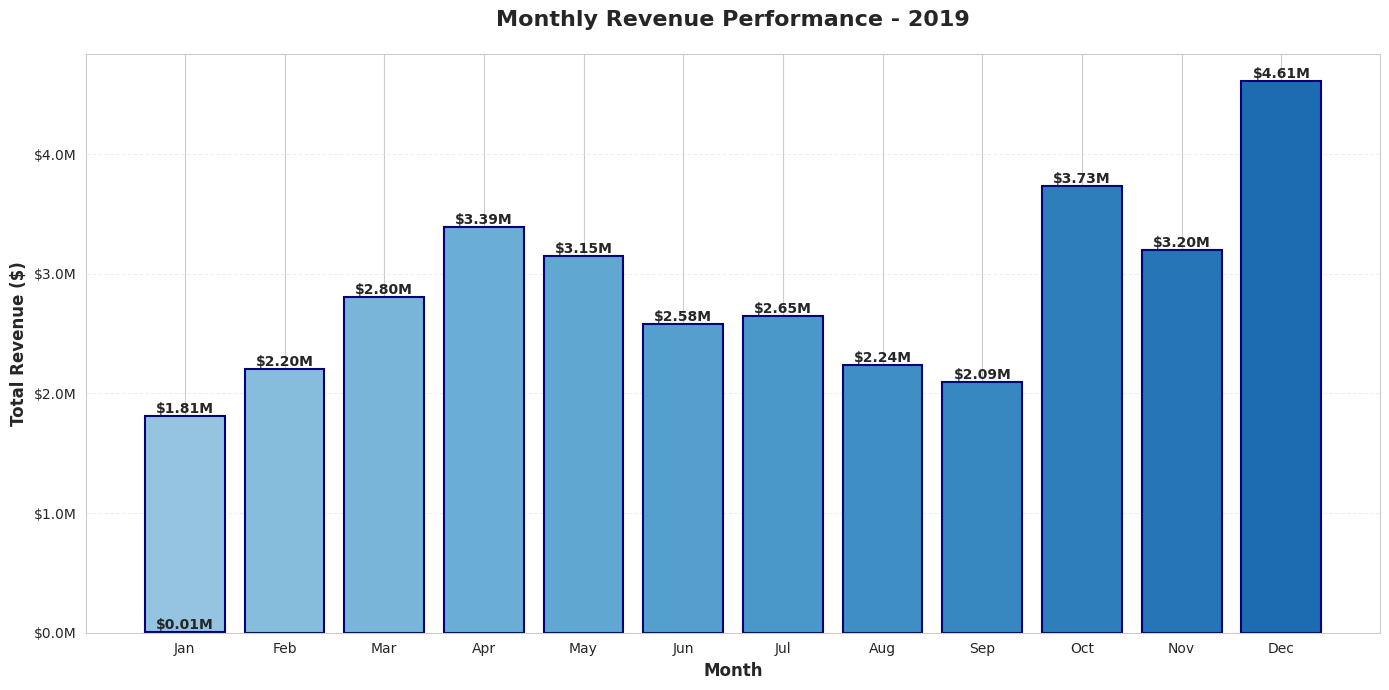

In [3]:
# Create revenue trend visualization
fig, ax = plt.subplots(figsize=(14, 7))

# Bar plot with gradient colors
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(monthly_df)))
bars = ax.bar(monthly_df['Month_Name'], monthly_df['Total_Revenue'], 
              color=colors, edgecolor='navy', linewidth=1.5)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height/1e6:.2f}M',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Formatting
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
ax.set_title('Monthly Revenue Performance - 2019', fontsize=16, fontweight='bold', pad=20)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../data/gold/monthly_revenue_trend.png', dpi=300, bbox_inches='tight')
plt.show()

# Convert product metrics to Pandas
product_df = product_metrics.limit(10).toPandas()

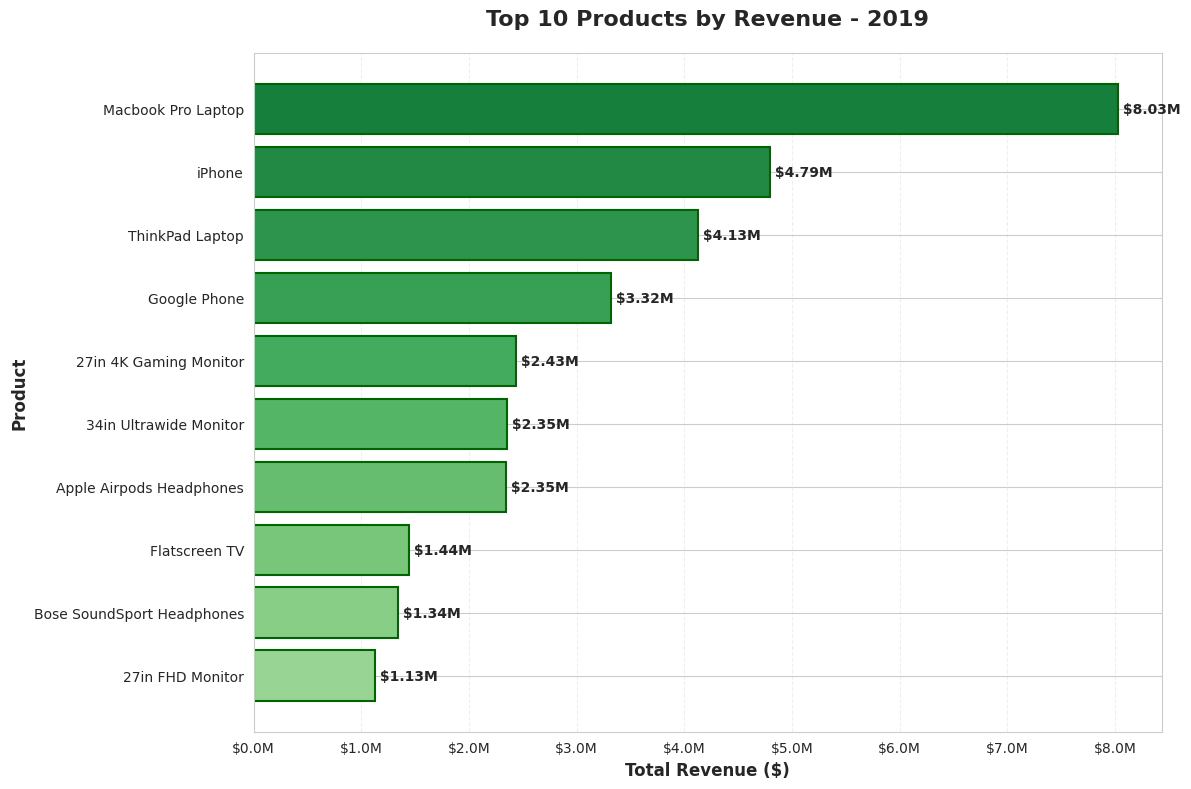

In [4]:
# Create horizontal bar chart for top products
fig, ax = plt.subplots(figsize=(12, 8))

# Sort by revenue and create color gradient
product_df_sorted = product_df.sort_values('Total_Revenue', ascending=True)
colors = plt.cm.Greens(np.linspace(0.4, 0.8, len(product_df_sorted)))

bars = ax.barh(product_df_sorted['Product'], product_df_sorted['Total_Revenue'],
               color=colors, edgecolor='darkgreen', linewidth=1.5)

# Add value labels
for i, (bar, revenue) in enumerate(zip(bars, product_df_sorted['Total_Revenue'])):
    ax.text(revenue, bar.get_y() + bar.get_height()/2.,
            f' ${revenue/1e6:.2f}M',
            ha='left', va='center', fontsize=10, fontweight='bold')

# Formatting
ax.set_xlabel('Total Revenue ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Product', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Products by Revenue - 2019', fontsize=16, fontweight='bold', pad=20)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../data/gold/top_products_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Calculate key business metrics
total_revenue = monthly_df['Total_Revenue'].sum()
total_orders = monthly_df['Total_Orders'].sum()
total_units = monthly_df['Total_Units_Sold'].sum()
avg_order_value = total_revenue / total_orders
best_month = monthly_df.loc[monthly_df['Total_Revenue'].idxmax()]
worst_month = monthly_df.loc[monthly_df['Total_Revenue'].idxmin()]

# Create summary report
summary = f"""
{'='*60}
EXECUTIVE SUMMARY - 2019 SALES PERFORMANCE
{'='*60}

ANNUAL METRICS:
  • Total Revenue:        ${total_revenue:,.2f}
  • Total Orders:         {total_orders:,}
  • Total Units Sold:     {total_units:,}
  • Average Order Value:  ${avg_order_value:.2f}

BEST PERFORMING MONTH:
  • Month:               {best_month['Month_Name']}
  • Revenue:             ${best_month['Total_Revenue']:,.2f}
  • Orders:              {best_month['Total_Orders']:,}

LOWEST PERFORMING MONTH:
  • Month:               {worst_month['Month_Name']}
  • Revenue:             ${worst_month['Total_Revenue']:,.2f}
  • Orders:              {worst_month['Total_Orders']:,}

TOP 3 PRODUCTS BY REVENUE:
"""

for i, row in product_df.head(3).iterrows():
    summary += f"  {i+1}. {row['Product']:<30} ${row['Total_Revenue']:>12,.2f}\n"

summary += f"\n{'='*60}\n"

print(summary)

# Save summary to text file
with open('../data/gold/executive_summary.txt', 'w') as f:
    f.write(summary)



EXECUTIVE SUMMARY - 2019 SALES PERFORMANCE

ANNUAL METRICS:
  • Total Revenue:        $34,465,075.45
  • Total Orders:         178,437
  • Total Units Sold:     208,730
  • Average Order Value:  $193.15

BEST PERFORMING MONTH:
  • Month:               Dec
  • Revenue:             $4,608,220.13
  • Orders:              24,004

LOWEST PERFORMING MONTH:
  • Month:               Jan
  • Revenue:             $8,670.29
  • Orders:              31

TOP 3 PRODUCTS BY REVENUE:
  1. Macbook Pro Laptop             $8,032,500.00
  2. iPhone                         $4,792,900.00
  3. ThinkPad Laptop                $4,127,958.72


